In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install yfinance
!pip install wordcloud
!pip install plotly



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 82.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go
     

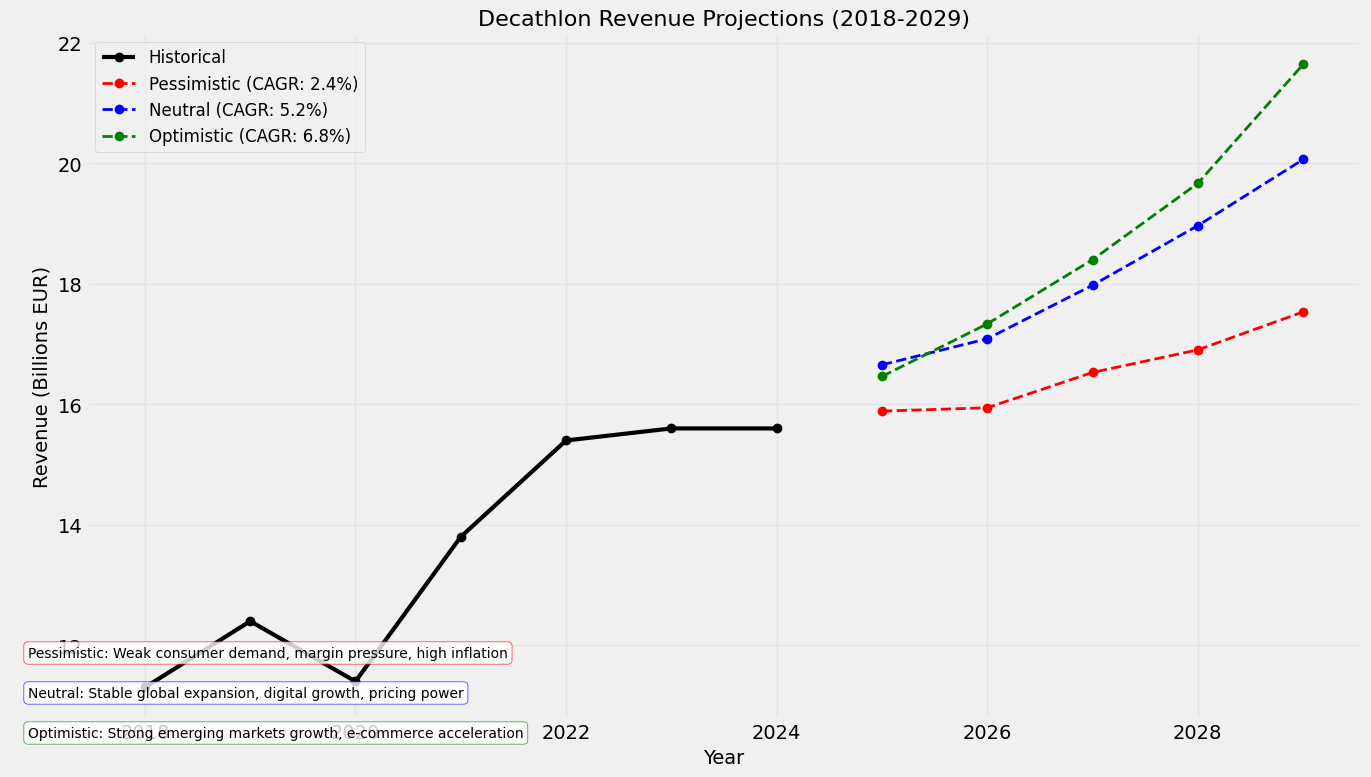

Decathlon Revenue Projections Analysis

Projected Revenue (2025-2029):
   Year  Pessimistic Revenue  Neutral Revenue  Optimistic Revenue
0  2025                15.89            16.66               16.46
1  2026                15.94            17.09               17.34
2  2027                16.53            17.98               18.40
3  2028                16.90            18.97               19.67
4  2029                17.53            20.07               21.64

Financial Analysis Summary:
      Scenario  CAGR (2024-2029)
0  Pessimistic            0.0237
1      Neutral            0.0516
2   Optimistic            0.0677


In [4]:

plt.style.use('fivethirtyeight')
sns.set_palette("deep")

# ==========================================
# HISTORICAL REVENUE – DECATHLON (EUR BN)
# Approximation based on public disclosures
# ==========================================

historical_revenue = {
    2018: 11.3,
    2019: 12.4,
    2020: 11.4,  # COVID impact (store closures)
    2021: 13.8,
    2022: 15.4,
    2023: 15.6,
    2024: 15.6   # Assumed stabilization
}

df_historical = pd.DataFrame(list(historical_revenue.items()), columns=['Year', 'Revenue'])
df_historical['Revenue_Type'] = 'Historical'

# ==========================================
# PROJECTION FUNCTION
# ==========================================

def generate_projections(years_to_project=5):

    current_year = 2024
    projection_years = range(current_year + 1, current_year + years_to_project + 1)

    scenarios = {

        'Pessimistic': {
            'growth_rate': np.linspace(0.01, 0.025, years_to_project),
            'volatility': 0.01,
            'description': 'Weak consumer demand, margin pressure, high inflation'
        },

        'Neutral': {
            'growth_rate': np.linspace(0.04, 0.055, years_to_project),
            'volatility': 0.015,
            'description': 'Stable global expansion, digital growth, pricing power'
        },

        'Optimistic': {
            'growth_rate': np.linspace(0.06, 0.08, years_to_project),
            'volatility': 0.02,
            'description': 'Strong emerging markets growth, e-commerce acceleration'
        }
    }

    latest_revenue = historical_revenue[current_year]
    projections = {}

    for scenario, params in scenarios.items():

        revenues = [latest_revenue]

        for i, year in enumerate(projection_years):

            growth_factor = 1 + params['growth_rate'][i] + np.random.normal(0, params['volatility'])
            new_revenue = revenues[-1] * growth_factor
            revenues.append(new_revenue)

        projections[scenario] = dict(zip(projection_years, revenues[1:]))

    return projections, scenarios

# Generate projections
projections, scenarios_info = generate_projections()

# Create projection dataframe
projection_data = []
for scenario, data in projections.items():
    for year, revenue in data.items():
        projection_data.append([year, revenue, scenario])

df_projections = pd.DataFrame(projection_data, columns=['Year', 'Revenue', 'Revenue_Type'])
df_combined = pd.concat([df_historical, df_projections])

# ==========================================
# CAGR CALCULATION
# ==========================================

def calculate_cagr(start_value, end_value, years):
    return (end_value / start_value) ** (1 / years) - 1

cagr_data = {}

for scenario in ['Pessimistic', 'Neutral', 'Optimistic']:
    scenario_data = df_projections[df_projections['Revenue_Type'] == scenario]
    end_year = max(scenario_data['Year'])
    start_value = historical_revenue[2024]
    end_value = scenario_data[scenario_data['Year'] == end_year]['Revenue'].values[0]
    years = end_year - 2024
    cagr_data[scenario] = calculate_cagr(start_value, end_value, years)

# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(14, 8))

# Historical
plt.plot(df_historical['Year'],
         df_historical['Revenue'],
         'o-', linewidth=3,
         color='black',
         label='Historical')

# Scenarios
colors = {'Pessimistic': 'red', 'Neutral': 'blue', 'Optimistic': 'green'}

for scenario in ['Pessimistic', 'Neutral', 'Optimistic']:
    scenario_data = df_projections[df_projections['Revenue_Type'] == scenario]
    plt.plot(scenario_data['Year'],
             scenario_data['Revenue'],
             'o--',
             linewidth=2,
             color=colors[scenario],
             label=f"{scenario} (CAGR: {cagr_data[scenario]:.1%})")

plt.title('Decathlon Revenue Projections (2018-2029)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Revenue (Billions EUR)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Scenario annotations
for i, (scenario, info) in enumerate(scenarios_info.items()):
    plt.annotate(f"{scenario}: {info['description']}",
                 xy=(0.02, 0.15 - i*0.05),
                 xycoords='figure fraction',
                 fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3",
                           fc="white",
                           ec=colors[scenario],
                           alpha=0.8))

plt.tight_layout()
plt.show()

# ==========================================
# FINANCIAL REPORT
# ==========================================

def generate_financial_report(historical, projections, cagr_data):

    report = pd.DataFrame()
    years = sorted(list(set([year for scenario in projections.values() for year in scenario.keys()])))
    report['Year'] = years

    for scenario in projections.keys():
        scenario_data = projections[scenario]
        report[f'{scenario} Revenue'] = [scenario_data.get(year, None) for year in years]

    report_summary = pd.DataFrame({
        'Scenario': list(projections.keys()),
        'CAGR (2024-2029)': [cagr_data[s] for s in projections.keys()]
    })

    return report, report_summary

financial_report, report_summary = generate_financial_report(
    historical_revenue,
    projections,
    cagr_data
)

print("Decathlon Revenue Projections Analysis")
print("======================================")
print("\nProjected Revenue (2025-2029):")
print(financial_report.round(2))

print("\nFinancial Analysis Summary:")
print(report_summary.round(4))

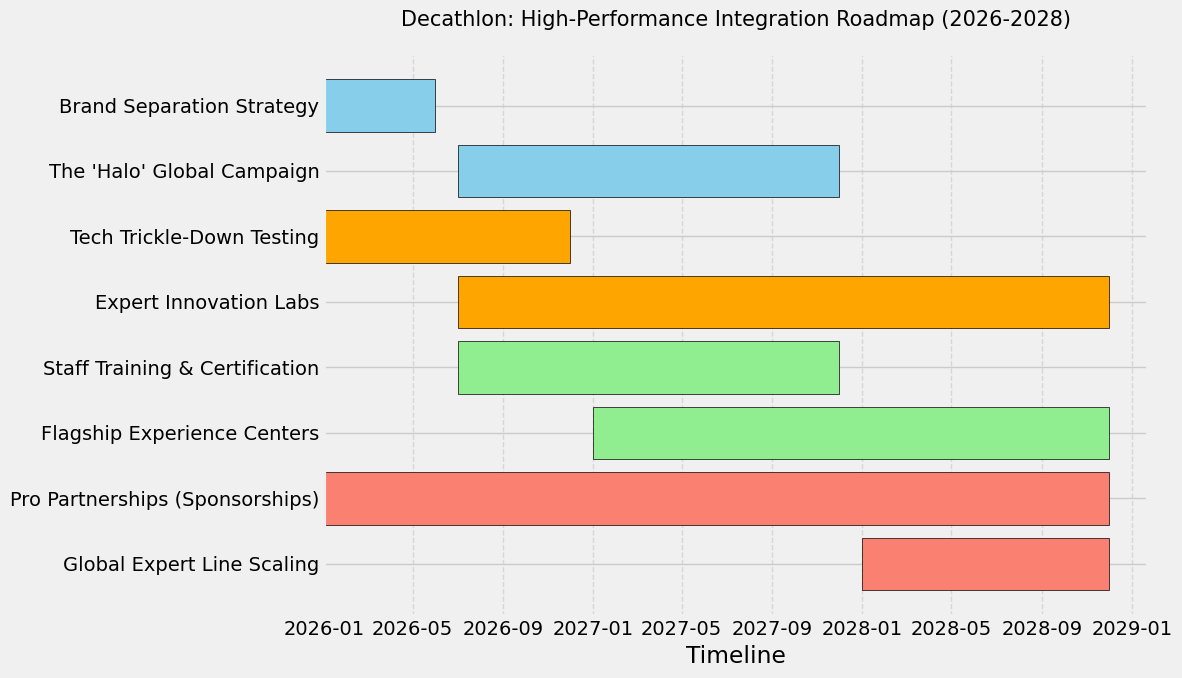

In [5]:

# 1. Setup the data
data = [
    dict(Phase="1. Branding", Action="Brand Separation Strategy", Start="2026-01", End="2026-06", Color='skyblue'),
    dict(Phase="1. Branding", Action="The 'Halo' Global Campaign", Start="2026-07", End="2027-12", Color='skyblue'),
    dict(Phase="2. R&D", Action="Tech Trickle-Down Testing", Start="2026-01", End="2026-12", Color='orange'),
    dict(Phase="2. R&D", Action="Expert Innovation Labs", Start="2026-07", End="2028-12", Color='orange'),
    dict(Phase="3. Retail", Action="Staff Training & Certification", Start="2026-07", End="2027-12", Color='lightgreen'),
    dict(Phase="3. Retail", Action="Flagship Experience Centers", Start="2027-01", End="2028-12", Color='lightgreen'),
    dict(Phase="4. Expansion", Action="Pro Partnerships (Sponsorships)", Start="2026-01", End="2028-12", Color='salmon'),
    dict(Phase="4. Expansion", Action="Global Expert Line Scaling", Start="2028-01", End="2028-12", Color='salmon')
]

df = pd.DataFrame(data)
df['Start'] = pd.to_datetime(df['Start'])
df['End'] = pd.to_datetime(df['End'])

# 2. Plotting
fig, ax = plt.subplots(figsize=(12, 7))

for i, row in df.iterrows():
    ax.barh(row['Action'], (row['End'] - row['Start']).days, left=row['Start'], color=row['Color'], edgecolor='black')

# Formatting
ax.set_title('Decathlon: High-Performance Integration Roadmap (2026-2028)', fontsize=15, pad=20)
ax.set_xlabel('Timeline')
ax.invert_yaxis()  # Labels read top-to-bottom
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [1]:
import plotly.graph_objects as go

# Configuration des données
header_values = ['<b>PHASE</b>', '<b>INVESTMENT</b>', '<b>INCREMENTAL REV.</b>', '<b>NET PROFIT</b>', '<b>CUMULATIVE ROI</b>']
cells_values = [
    ["Year 1 (Setup)", "Year 2 (Scaling)", "Year 3 (Maturity)"],
    ["-€150M", "-€100M", "-€50M"],
    ["€50M", "€250M", "€600M"],
    ["-€40M", "€60M", "€180M"],
    ["-26%", "13%", "130%"]
]

# Création du tableau
fig = go.Figure(data=[go.Table(
    # Configuration des largeurs de colonnes (plus larges pour les titres)
    columnwidth = [120, 100, 150, 110, 120],
    
    header=dict(
        values=header_values,
        fill_color='#007DBC', # Bleu Décathlon
        align='center',
        font=dict(color='white', size=13),
        height=45
    ),
    cells=dict(
        values=cells_values,
        # Couleurs de fond pour les lignes : Blanc pour tout, sauf les indicateurs de performance
        fill_color=[
            ['white']*3, # Phase
            ['white']*3, # Investment
            ['white']*3, # Revenue
            ['#FFCCCC', '#E6F3FF', '#D1FFD1'], # Net Profit (Rouge -> Bleu -> Vert)
            ['#FFCCCC', '#E6F3FF', '#2ECC71']  # ROI (Rouge -> Bleu -> Vert)
        ],
        align='center',
        font=dict(color='black', size=12),
        height=40
    )
)])

fig.update_layout(
    title="Strategic Financial Forecast: High-Performance Integration",
    title_x=0.5,
    margin=dict(l=10, r=10, t=60, b=10)
)

fig.show()